In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
def train_df(tr_path):
    classes = []
    class_paths = []
    files = os.listdir(tr_path)
    for file in files:
        label_dir = os.path.join(tr_path, file)
        label = os.listdir(label_dir)
        for image in label:
            image_path = os.path.join(label_dir, image)
            class_paths.append(image_path)
            classes.append(file)
    image_classes = pd.Series(classes, name='Class')
    image_paths = pd.Series(class_paths, name='Class Path')
    tr_df = pd.concat([image_paths, image_classes], axis=1)
    return tr_df

In [12]:
tr_df = train_df('OS Collected Data')
tr_df

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'OS Collected Data'

In [6]:
train_df, dummies_df = train_test_split(tr_df, test_size=0.2, random_state=42)
valid_df, test_df = train_test_split(dummies_df, test_size=0.5, random_state=42)

NameError: name 'tr_df' is not defined

In [6]:
batch_size = 16
img_size = (224,224)

tr_gen = ImageDataGenerator(brightness_range=(.8,1.2))

gen = ImageDataGenerator()


tr_gen = tr_gen.flow_from_dataframe(train_df, x_col='Class Path',
                                 y_col='Class',batch_size=batch_size,
                                 target_size=img_size)

valid_gen = gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                    y_col='Class',batch_size=batch_size,
                                    target_size=img_size)

ts_gen = gen.flow_from_dataframe(test_df, x_col='Class Path',
                                y_col='Class',batch_size=batch_size,
                                 target_size=img_size,shuffle=False)

Found 1557 validated image filenames belonging to 3 classes.
Found 195 validated image filenames belonging to 3 classes.
Found 195 validated image filenames belonging to 3 classes.


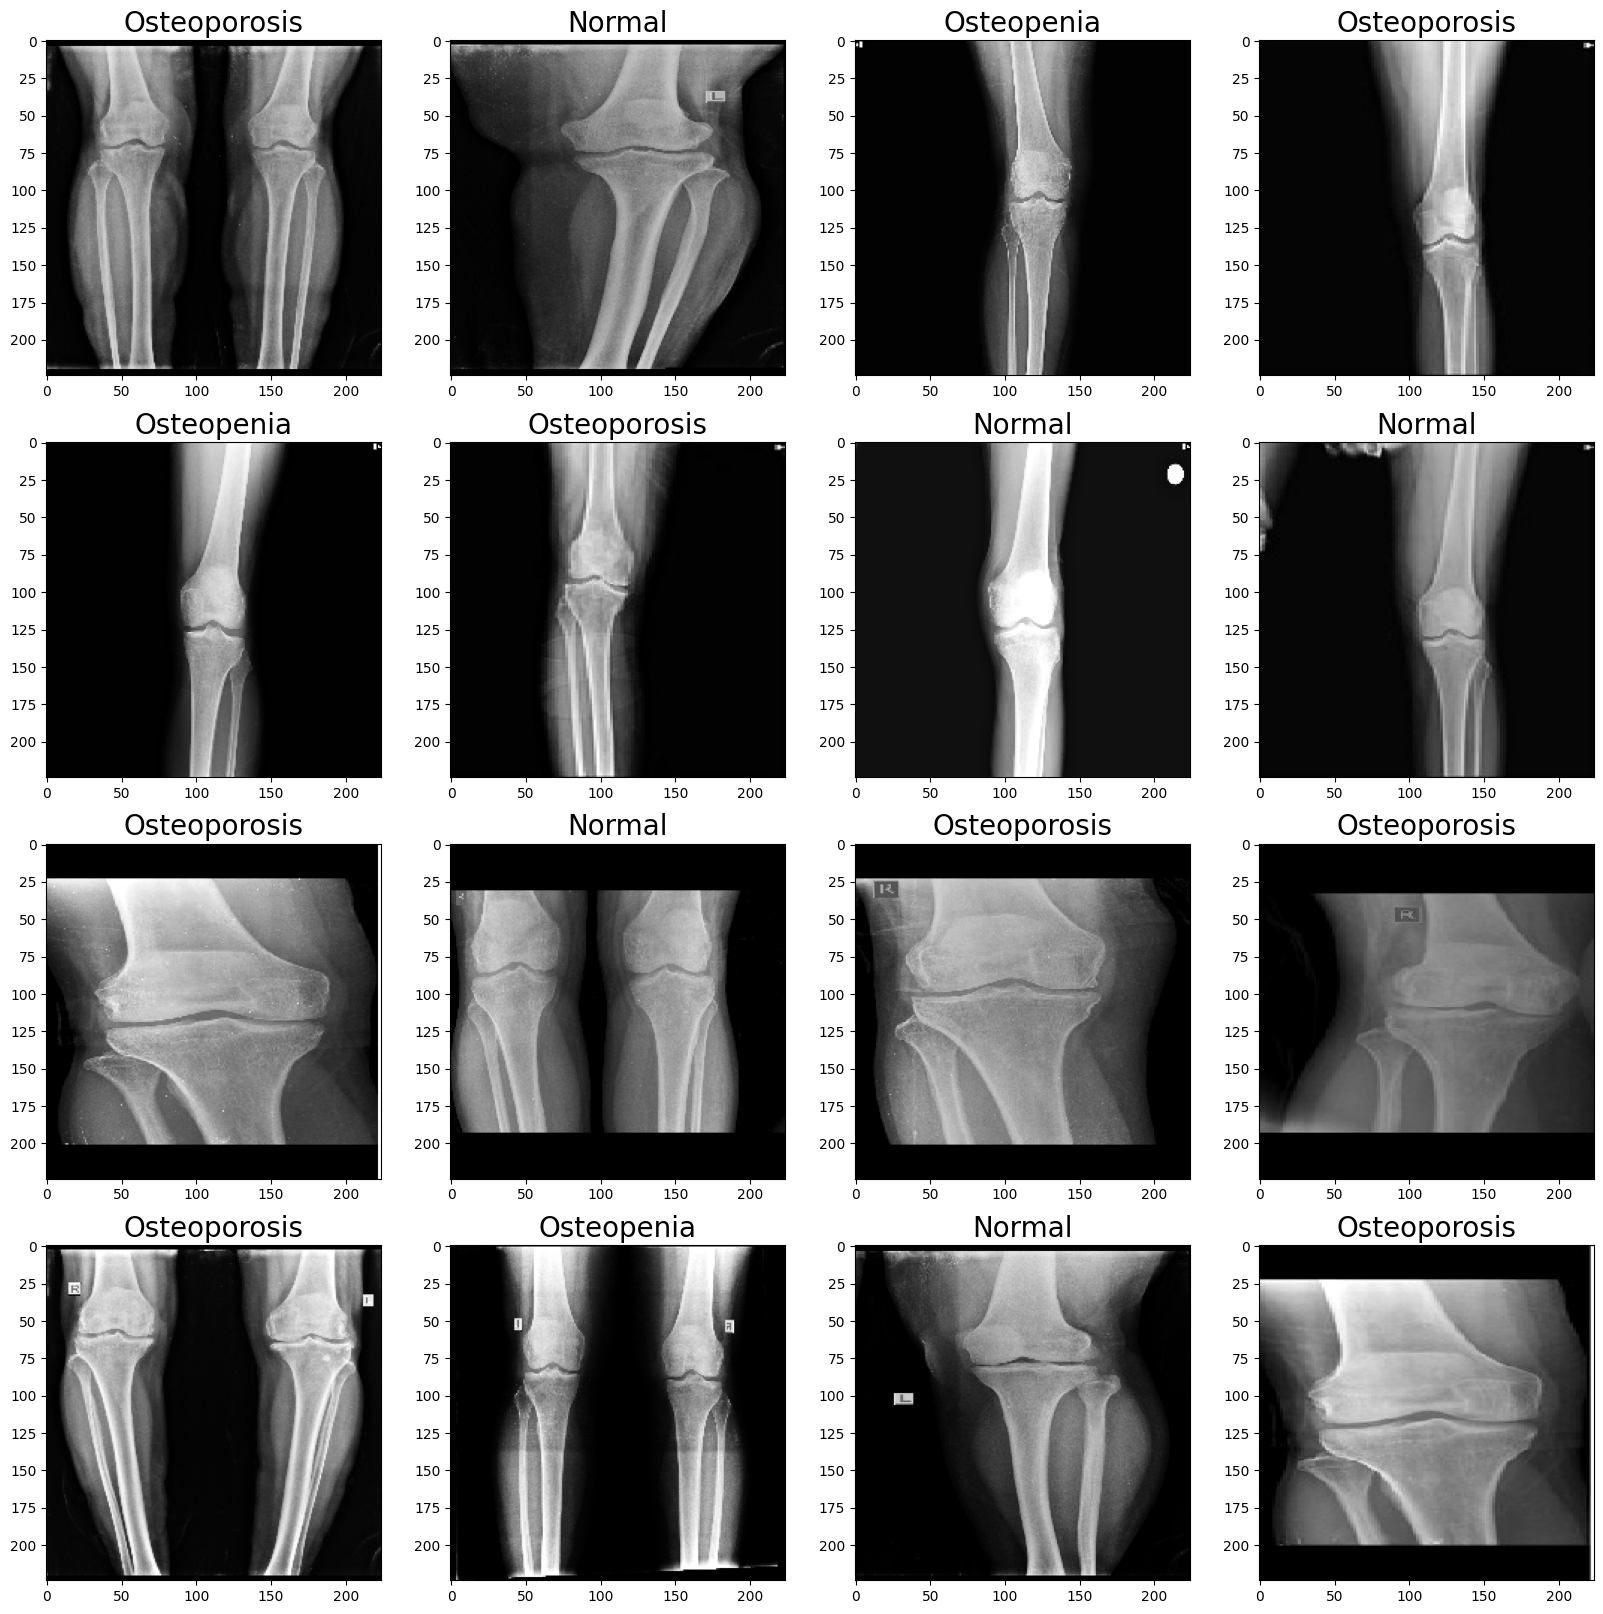

In [7]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(tr_gen)
plt.figure(figsize= (20, 20))
for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color='k', fontsize=20)
plt.show()

In [8]:
num_classes = len(classes)
num_classes

3

In [9]:
img_shape=(224,224,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')
    
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(num_classes, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'binary_crossentropy',
              metrics= ['accuracy'])
model.build((None, 224, 224, 3))
model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,139 (80.58 MB)

 Trainable params: 21,069,611 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [10]:
history = model.fit(tr_gen,
                 epochs=50,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 360s 3s/step - accuracy: 0.5853 - loss: 0.5817 - val_accuracy: 0.6615 - val_loss: 0.3943
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 343s 3s/step - accuracy: 0.8427 - loss: 0.2610 - val_accuracy: 0.8462 - val_loss: 0.2388
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 347s 4s/step - accuracy: 0.8864 - loss: 0.1863 - val_accuracy: 0.8462 - val_loss: 0.3063
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.9189 - loss: 0.1397 - val_accuracy: 0.8769 - val_loss: 0.2291
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 306s 3s/step - accuracy: 0.9119 - loss: 0.1377 - val_accuracy: 0.8513 - val_loss: 0.2331
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.9230 - loss: 0.1135 - val_accuracy: 0.8615 - val_loss: 0.2573
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 290s 3s/step - accuracy: 0.9258 - loss: 0.0962 - val_accuracy: 0.8923 - val_loss: 0.2230
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.9416 - loss: 0.0793 - val_accuracy: 0.8462 - v

In [11]:
model.evaluate(ts_gen, verbose=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 753ms/step - accuracy: 0.8934 - loss: 0.4361


[0.36458465456962585, 0.9128205180168152]

In [12]:
model.save("knee_Model.h5")

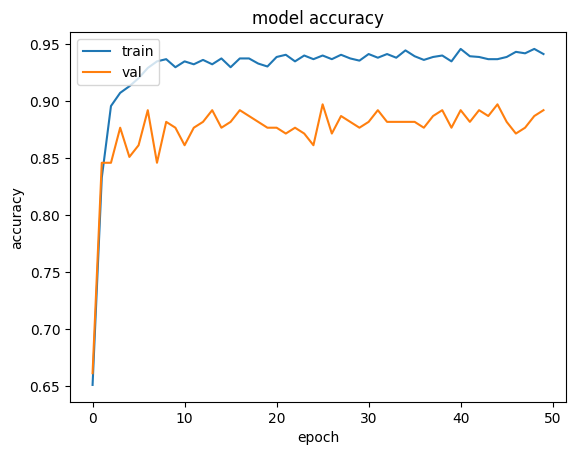

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

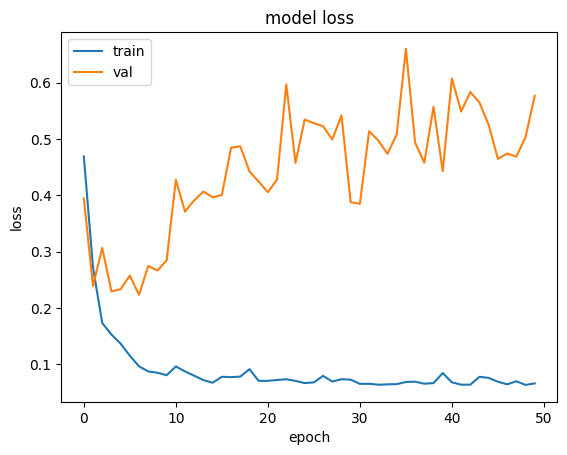

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [15]:
pred = model.predict(ts_gen)
pred = np.argmax(pred, axis=1)

labels = (tr_gen.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 715ms/step


In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_df['Class']
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

              precision    recall  f1-score   support

      Normal       0.94      0.92      0.93        89
  Osteopenia       0.86      0.86      0.86        36
Osteoporosis       0.90      0.93      0.92        70

    accuracy                           0.91       195
   macro avg       0.90      0.90      0.90       195
weighted avg       0.91      0.91      0.91       195

Accuracy of the Model: 91.3%


In [17]:
classes=list(tr_gen.class_indices.keys())
print (classes)

['Normal', 'Osteopenia', 'Osteoporosis']


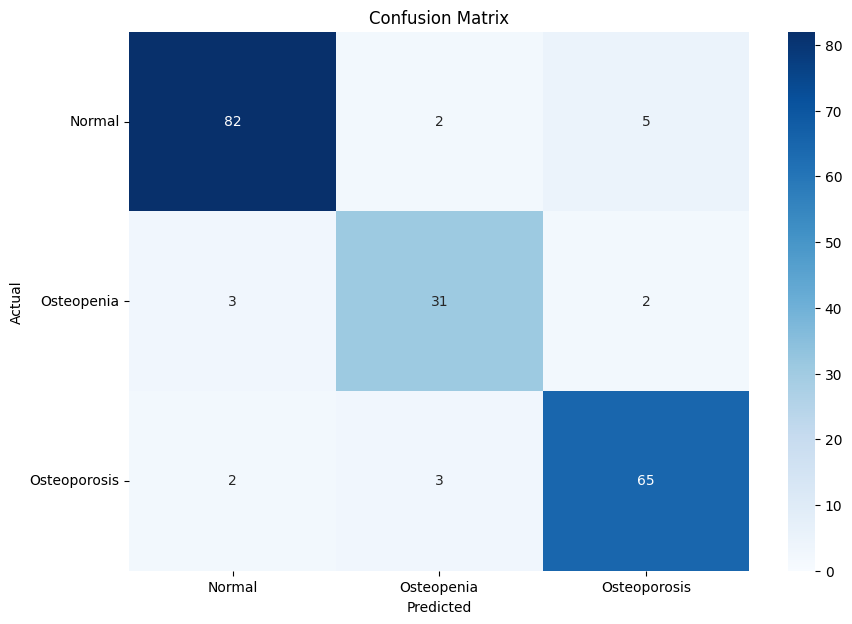

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = test_df['Class'].values
cm = confusion_matrix(y_true, pred2)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

num_classes = len(classes)

plt.xticks(ticks=[i + 0.5 for i in range(num_classes)], labels=classes, rotation=0)
plt.yticks(ticks=[i + 0.5 for i in range(num_classes)], labels=classes, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()